In [14]:
# basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [15]:
# loading dataset

df = pd.read_csv('../data/q2_customers.csv')

# just checking
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [16]:
# basic check

print(df.shape)
print(df.isnull().sum())

(500, 6)
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


In [17]:
# filling missing values (just in case)

df = df.fillna(df.median(numeric_only=True))

In [18]:
# scaling data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Scaling is important because K-Means uses distance.
If features are on different scales, results can be biased.
So scaling makes all features equally important.

In [19]:
# finding best K

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

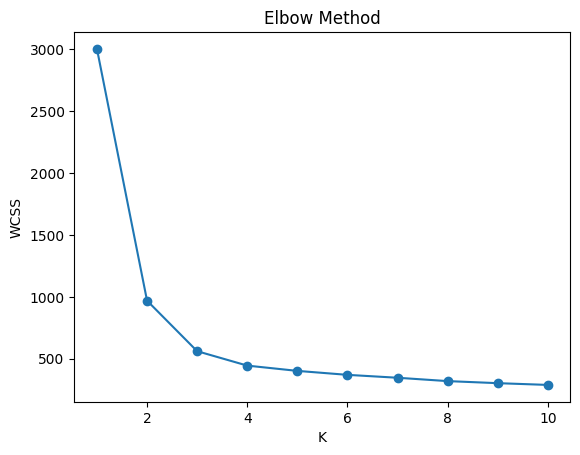

In [20]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

The graph shows a clear bend around K = 3.
So choosing 3 clusters is reasonable.

In [21]:
# applying clustering

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_data)

# adding cluster column
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [22]:
# cluster centers

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0 represents low spending and less frequent customers.

Cluster 1 represents average customers.

Cluster 2 represents high spending and frequent customers.

In [23]:
# PCA for visualization

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [24]:
print(pca.explained_variance_ratio_)

[0.83560354 0.05568764]


In [25]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 captures overall spending behavior.

PC2 captures differences in visit frequency.

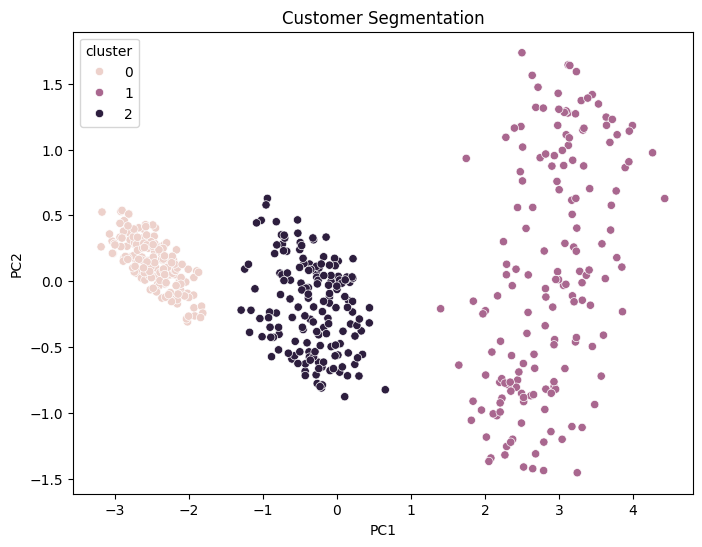

In [26]:
# visualization

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df)

plt.title("Customer Segmentation")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()